# TD - Financial Reporting

Lisez bien le [README.md](README.md) avant de commencer 📖

> **VS Code** : ouvrez le fichier puis `CTRL+SHIFT+V` pour le prévisualiser 

In [1]:
# Dépendances du notebook
%pip install openpyxl==3.1.3 pandas==3.0.2 s3fs==2026.3.0 -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlflow 3.11.1 requires pandas<3, but you have pandas 3.0.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

df = pd.read_parquet(
    "https://minio.lab.sspcloud.fr/fabienhos/td-reporting-financial/financial_data.parquet"
)

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   client_id      25000 non-null  int64         
 1   type_client    25000 non-null  str           
 2   date_adhesion  25000 non-null  datetime64[ms]
 3   score          23674 non-null  str           
 4   score_prev     23588 non-null  str           
 5   id_agent       25000 non-null  str           
 6   drc_complet    25000 non-null  bool          
dtypes: bool(1), datetime64[ms](1), int64(1), str(4)
memory usage: 1.4 MB


,client_id,type_client,date_adhesion,score,score_prev,id_agent,drc_complet
0,1,PP,1980-05-25 14:41:06,O,V,AUTO,False
1,2,PM,2001-11-25 10:36:55,V,R,AUTO,True
2,3,PP,2021-02-05 02:47:32,V,V,AUTO,True
3,4,PP,2013-08-14 02:45:04,V,V,AUTO,True
4,5,PP,1985-06-05 01:26:17,V,V,AUTO,True


### Inspectez la présence de valeurs manquantes

In [9]:
df.count()

client_id        25000
type_client      25000
date_adhesion    25000
score            23674
score_prev       23588
id_agent         25000
drc_complet      25000
dtype: int64

Il y a des valeurs manquantes dans les champs score et score_prev.

In [12]:
df["score"].value_counts(dropna=False)

score
V      17400
O       5032
NaN     1326
R       1242
Name: count, dtype: int64

In [11]:
df["score_prev"].value_counts(dropna=False)

score_prev
V      14871
O       5060
R       3657
NaN     1412
Name: count, dtype: int64

Pour score_prev, on peut penser que les valeurs manquantes sont liées à une adhésion récente, nous n'avons donc pas l'année précédente. Pour score, on peut penser que les valeurs manquantes sont liées à un départ du client sur l'année en cours.

On va créer des sous effectifs des valeurs NA et vérifier la date d'adhésion

In [ ]:
df_score_prev_na = df.loc[df["score_prev"].isna() == True, :]

In [21]:
df_score_prev_na.sort_values("date_adhesion")

,client_id,type_client,date_adhesion,score,score_prev,id_agent,drc_complet
15114,15115,PP,1980-01-06 04:55:38,V,NaN,AUTO,True
18628,18629,PM,1980-02-01 05:27:39,V,NaN,AUTO,True
2035,2036,PM,1980-02-04 07:45:48,O,NaN,AUTO,True
2265,2266,PP,1980-02-11 22:38:06,V,NaN,AUTO,True
2321,2322,PM,1980-02-25 12:05:47,V,NaN,AUTO,True
...,...,...,...,...,...,...,...
16176,16177,PM,2025-04-25 23:37:24,V,NaN,AUTO,True
24568,24569,PP,2025-04-26 07:54:28,V,NaN,AUTO,True
2645,2646,PP,2025-04-26 17:00:39,V,NaN,AUTO,False
1220,1221,PP,2025-04-27 07:17:39,V,NaN,AUTO,True


On observe que ce n'est pas lié aux dates, elles vont de 1980 à 2025. Par contre peut être que c'est lié à la nature d'id_agent.

In [24]:
df_score_prev_na.value_counts("id_agent")

id_agent
AUTO        1356
AGENT_7        8
AGENT_4        8
AGENT_6        7
AGENT_3        7
AGENT_9        6
AGENT_2        6
AGENT_8        4
AGENT_5        4
AGENT_10       3
AGENT_1        3
Name: count, dtype: int64

In [30]:
df_score_prev_na.loc[df["id_agent"] == "AGENT_4", :]

,client_id,type_client,date_adhesion,score,score_prev,id_agent,drc_complet
4173,4174,PP,2000-05-13 18:14:31,R,NaN,AGENT_4,True
5424,5425,PM,2022-03-13 10:04:06,R,NaN,AGENT_4,True
9630,9631,PM,2025-03-26 16:06:17,R,NaN,AGENT_4,False
10192,10193,PP,2025-04-02 08:25:59,R,NaN,AGENT_4,True
16782,16783,PM,1989-01-30 11:26:58,R,NaN,AGENT_4,False
23489,23490,PM,2025-04-06 18:18:49,R,NaN,AGENT_4,True
23508,23509,PP,1990-11-15 21:17:08,R,NaN,AGENT_4,True
24553,24554,PP,2025-03-03 10:46:50,R,NaN,AGENT_4,True


Beaucoup d'enregistrements ont été effectué par l'agent AUTO. On va vérifier si on a le même comportement pour les score manquants

In [25]:
df_score_na = df.loc[df["score"].isna() == True, :]

In [29]:
df_score_na

,client_id,type_client,date_adhesion,score,score_prev,id_agent,drc_complet
25,26,PM,1997-05-22 21:35:01,NaN,V,AUTO,True
49,50,PM,2011-12-13 00:37:41,NaN,V,AUTO,False
83,84,PM,1989-08-09 00:51:34,NaN,V,AUTO,False
98,99,PM,1993-03-24 12:08:06,NaN,R,AUTO,True
118,119,PM,1989-03-02 07:05:54,NaN,V,AUTO,True
...,...,...,...,...,...,...,...
24865,24866,PP,2024-09-24 23:00:08,NaN,V,AUTO,True
24866,24867,PM,2024-02-20 06:29:39,NaN,O,AUTO,False
24920,24921,PP,2023-12-21 18:43:34,NaN,V,AUTO,True
24933,24934,PP,2014-09-16 03:51:14,NaN,V,AUTO,True


In [28]:
df_score_na.value_counts("id_agent")

id_agent
AUTO    1326
Name: count, dtype: int64

Les scores manquants proviennent uniquement de l'agent AUTO.

#### Questions
1. Quelle stratégie adopter ?
2. Quelles sont les hypothèses que vous pourriez émettre afin d'expliquer ces valeurs manquantes ?
3. Comment pourriez-vous les vérifier ?

### Explorez les variables disponibles

Utilisez des counts, des tableaux croisés, des graphiques ...

```python
df['type_client'].value_counts()
pd.crosstab(df['score'], df['score_prev'])
```

In [31]:
pd.crosstab(df["score"], df["score_prev"])

score_prev,O,R,V
score,,,
O,971,744,3021
R,242,184,756
V,3603,2532,10283


In [32]:
df["type_client"].value_counts()

type_client
PM    12502
PP    12498
Name: count, dtype: int64

array([[<Axes: title={'center': 'AGENT_1'}>,
        <Axes: title={'center': 'AGENT_10'}>,
        <Axes: title={'center': 'AGENT_2'}>],
       [<Axes: title={'center': 'AGENT_3'}>,
        <Axes: title={'center': 'AGENT_4'}>,
        <Axes: title={'center': 'AGENT_5'}>],
       [<Axes: title={'center': 'AGENT_6'}>,
        <Axes: title={'center': 'AGENT_7'}>,
        <Axes: title={'center': 'AGENT_8'}>],
       [<Axes: title={'center': 'AGENT_9'}>,
        <Axes: title={'center': 'AUTO'}>, <Axes: >]], dtype=object)

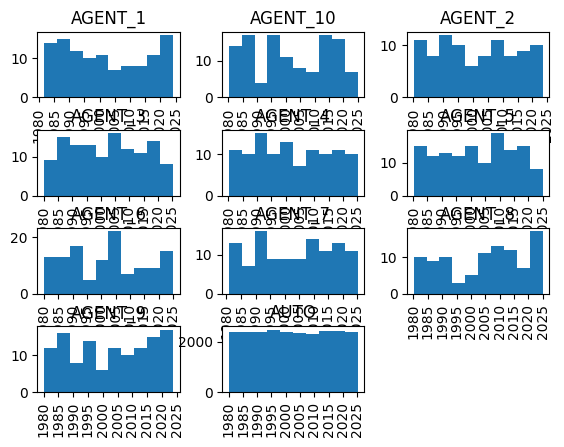

In [36]:
df.hist(column="date_adhesion", by="id_agent")

Rédigez vos observations sur les variables ici

Observations :

### Traitez les données nécessaires

Il faut remplacer les valeurs manquantes par une valeur physique pour le traitement excel

In [42]:
df = df.fillna("NA")

In [43]:
df.value_counts("score")

score
V     17400
O      5032
NA     1326
R      1242
Name: count, dtype: int64

### Génération du rapport Excel

In [44]:
path_file = "template/template_reporting.xlsx"

with pd.ExcelWriter(
    path_file, mode="a", engine="openpyxl", if_sheet_exists="replace"
) as writer:
    df.to_excel(writer, sheet_name="DATA", index=False)

Si vous téléchargez le fichier Excel depuis `template/template_reporting.xlsx` vous constaterez qu'une page contenant le DataFrame a été ajouté. 

Nous sommes dans une situation idéale pour construire nos indicateurs 👀

In [52]:
from openpyxl import load_workbook

# Il faut charger en mémoire le fichier
wb = load_workbook(path_file)

# Puis récupérer la feuille
ws = wb["Indicateurs"]

# On peut maintenant ajouter des formules
# 1. Nombre de clients PP
ws["E8"] = '=COUNTIF(DATA!B:B, "PP")'

# 2. Nombre de clients PM
ws["E9"] = '=COUNTIF(DATA!B:B, "PM")'

ws["E10"] = "=SUM(E8:E9)"

# à vous de continuer pour les autres indicateurs 💻
ws["E14"] = '=COUNTIF(DATA!D:D, "V")'

ws["E15"] = '=COUNTIF(DATA!D:D, "O")'

ws["E16"] = '=COUNTIF(DATA!D:D, "R")'

ws["E17"] = '=COUNTIF(DATA!D:D, "NA")'

ws["E18"] = "=SUM(E14:E17)"

wb.save(path_file)
wb.close()

In [59]:
def countif(plage, condition):
    return f'=COUNTIF({plage}, "{condition}")'

In [61]:
def countifs(plage1, condition1, plage2, condition2):
    return f'=COUNTIFs({plage1}, "{condition1}",{plage2}, "{condition2}")'

In [ ]:
ws["E22"] = countifs("DATA!B:B", "PP", "DATA!G:G", "VRAI")
ws["E23"] = countifs("DATA!B:B", "PM", "DATA!G:G", "VRAI")
wb.save(path_file)
wb.close()

### Commentaire

Comme vous pouvez le voir, remplir ce fichier ne sera pas un soucis, c'est très simple de copier/coller la formule X fois en l'adaptant à la question.

Je vous invite à prendre un peu de recul sur ce que vous faites et à chercher s'il n'existerait pas une solution plus adapté.

Indices : data structures, fonctions, dataclass ... ?